In [4]:
import pandas as pd
round_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\round.csv")

round_df = round_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')


print("round:", round_df.shape)
print("\n cols:", list(round_df.columns))
print("\n--- top five  ---")
print(round_df.head())
print("\n--- uniqe name ---")
print(sorted(round_df['name'].dropna().unique()))

round: (9243, 5)

 cols: ['match_id', 'round_id', 'name', 'slug', 'cup_round_type']

--- top five  ---
   match_id  round_id         name         slug  cup_round_type
0  11998445         5  Round of 16  round-of-16             8.0
1  11998446         5  Round of 16  round-of-16             8.0
2  11998447         5  Round of 16  round-of-16             8.0
3  11998448         5  Round of 16  round-of-16             8.0
4  11998449         5  Round of 16  round-of-16             8.0

--- uniqe name ---
['Final', 'Qualification round 1', 'Qualification round 2', 'Quarterfinal', 'Quarterfinals', 'Round of 128', 'Round of 16', 'Round of 32', 'Round of 64', 'Semifinal', 'Semifinals']


In [5]:
finals_df = round_df[round_df['name'] == 'Final'].copy()

print("rows with name=Final:", len(finals_df))
print("uniqe match_id count:", finals_df['match_id'].nunique())
print("duplicated match_id :", finals_df['match_id'].duplicated().sum())

rows with name=Final: 260
uniqe match_id count: 260
duplicated match_id : 0


In [6]:
event_df= pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\event.csv")
home_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\home_team.csv")
away_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\away_team.csv")

event_df = event_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')
home_df = home_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')
away_df = away_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')

event_clean = event_df[['match_id', 'winner_code', 'start_datetime']].dropna(subset=['winner_code'])
home_clean = home_df[['match_id', 'player_id', 'full_name']]
away_clean = away_df[['match_id', 'player_id', 'full_name']]

#keep final matches only
finals_merged = finals_df[['match_id']].merge(event_clean, on='match_id', how='inner')
finals_merged = finals_merged.merge(home_clean, on='match_id', how='inner')
finals_merged = finals_merged.merge(away_clean, on='match_id', how='inner', suffixes=('_home', '_away'))

print("تعداد فینال‌هایی که همه اطلاعاتشون کامله:", len(finals_merged))
print(finals_merged.head())

تعداد فینال‌هایی که همه اطلاعاتشون کامله: 225
   match_id  winner_code  start_datetime  player_id_home      full_name_home  \
0  12002073          1.0      1707051600           64496   Ostapenko, Jelena   
1  12002069          1.0      1707042600          318575     Shnaider, Diana   
2  11998663          1.0      1707012000           79467        Jasika, Omar   
3  11999016          1.0      1707051600          200159     Rodionov, Jurij   
4  12038725          2.0      1707031800          329533  Vilicich, Bautista   

   player_id_away           full_name_away  
0           67759   Alexandrova, Ekaterina  
1           45584                 Zhu, Lin  
2           58369               Bolt, Alex  
3          235576       Nakashima, Brandon  
4          177686  Barranco Cosano, Javier  


In [7]:
import numpy as np

# choose winner 
finals_merged['winner_id'] = np.where(finals_merged['winner_code'] == 1, finals_merged['player_id_home'], finals_merged['player_id_away'])
finals_merged['winner_name'] = np.where(finals_merged['winner_code'] == 1, finals_merged['full_name_home'], finals_merged['full_name_away'])

# تبدیل start_datetime (که یه unix timestamp هست، یعنی ثانیه از 1970) به تاریخ واقعی
finals_merged['match_date'] = pd.to_datetime(finals_merged['start_datetime'], unit='s')
finals_merged['year_month'] = finals_merged['match_date'].dt.to_period('M')

print(finals_merged[['match_id', 'winner_name', 'match_date', 'year_month']].head(10))

   match_id              winner_name          match_date year_month
0  12002073        Ostapenko, Jelena 2024-02-04 13:00:00    2024-02
1  12002069          Shnaider, Diana 2024-02-04 10:30:00    2024-02
2  11998663             Jasika, Omar 2024-02-04 02:00:00    2024-02
3  11999016          Rodionov, Jurij 2024-02-04 13:00:00    2024-02
4  12038725  Barranco Cosano, Javier 2024-02-04 07:30:00    2024-02
5  12038651       Moroni, Gian Marco 2024-02-04 08:30:00    2024-02
6  12039714         Tiurnev, Evgenii 2024-02-04 08:30:00    2024-02
7  12038552            Gengel, Marek 2024-02-04 08:00:00    2024-02
8  12039364         Bouquier, Arthur 2024-02-04 09:55:00    2024-02
9  12039718    Miyazaki, Yuriko Lily 2024-02-04 13:30:00    2024-02


In [8]:
champion_month_counts = finals_merged.groupby(['winner_id', 'winner_name', 'year_month']).size().reset_index(name='titles')
champion_month_counts = champion_month_counts.sort_values('titles', ascending=False)

print(champion_month_counts.head(10))

     winner_id                        winner_name year_month  titles
14       50901                      Popko, Dmitry    2024-02       3
180     372311                       Nicod, Jakub    2024-03       3
124     230049              Jianu, Filip Cristian    2024-03       3
99      202572                      Gengel, Marek    2024-02       3
17       52533                  Jakupovic, Dalila    2024-03       2
40       82133  Dellien Velasco, Murkel Alejandro    2024-02       2
26       63642              Kwiatkowski, Thai-Son    2024-03       2
71      152766                      Helgo, Malene    2024-03       2
100     205282                  Kužmová, Katarína    2024-02       2
154     293708                      Boisson, Loïs    2024-03       2


**QUESTION TEN**

In [9]:
import pandas as pd

home_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\home_team.csv")
away_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\away_team.csv")

players = pd.concat([
    home_df[['player_id', 'full_name', 'height', 'current_rank']],
    away_df[['player_id', 'full_name', 'height', 'current_rank']]
], ignore_index=True).drop_duplicates(subset='player_id')

print("تعداد کل بازیکن یکتا:", len(players))
print("\nتعداد null در height:", players['height'].isnull().sum())
print("تعداد null در current_rank:", players['current_rank'].isnull().sum())

print("\n--- آمار توصیفی current_rank ---")
print(players['current_rank'].describe())

تعداد کل بازیکن یکتا: 2644

تعداد null در height: 1327
تعداد null در current_rank: 71

--- آمار توصیفی current_rank ---
count    2573.000000
mean      745.097940
std       454.232715
min         1.000000
25%       343.000000
50%       717.000000
75%      1156.000000
max      1858.000000
Name: current_rank, dtype: float64


In [10]:
players_valid = players.dropna(subset=['height', 'current_rank'])

print("تعداد بازیکنانی که هم height هم rank دارن:", len(players_valid))

correlation = players_valid['height'].corr(players_valid['current_rank'])
print(f"\nضریب همبستگی پیرسون بین height و current_rank: {correlation:.4f}")

تعداد بازیکنانی که هم height هم rank دارن: 1307

ضریب همبستگی پیرسون بین height و current_rank: 0.1051


**QUESTION ELEVEN**

In [12]:
import pandas as pd

time_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\time.csv")

print("قبل از حذف تکراری:", time_df.shape)

time_df = time_df.drop_duplicates()
time_df = time_df.drop_duplicates(subset='match_id', keep='first')

print("بعد از حذف تکراری:", time_df.shape)

قبل از حذف تکراری: (35671, 7)
بعد از حذف تکراری: (16873, 7)


In [13]:
period_cols = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']

for col in period_cols:
    time_df.loc[(time_df[col] < 0) | (time_df[col] < 300), col] = pd.NA

In [18]:
time_df['total_duration'] = time_df[period_cols].sum(axis=1, skipna=True)

# matchهایی که هیچ پریود معتبری ندارن، باید NaN بمونن نه صفر
has_any_period = time_df[period_cols].notnull().any(axis=1)
time_df.loc[~has_any_period, 'total_duration'] = pd.NA

print("تعداد match با مدت‌زمان معتبر (قبل از فیلتر outlier):", time_df['total_duration'].notnull().sum())

تعداد match با مدت‌زمان معتبر (قبل از فیلتر outlier): 10320


In [ ]:
# چک کردن داده مون با ای کیو ای محض اظمینان
Q1 = time_df['total_duration'].quantile(0.25)
Q3 = time_df['total_duration'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25%): {Q1:.1f} ثانیه")
print(f"Q3 (75%): {Q3:.1f} ثانیه")
print(f"IQR: {IQR:.1f} ثانیه")
print(f"حد بالای مجاز (Q3 + 1.5×IQR): {upper_bound:.1f} ثانیه = {upper_bound/3600:.2f} ساعت")

Q1 (25%): 4633.0 ثانیه
Q3 (75%): 7524.2 ثانیه
IQR: 2891.2 ثانیه
حد بالای مجاز (Q3 + 1.5×IQR): 11861.1 ثانیه = 3.29 ساعت


In [19]:
MAX_REALISTIC_DURATION = 21600  # 6 ساعت

time_df_clean = time_df[
    time_df['total_duration'].isnull() | (time_df['total_duration'] <= MAX_REALISTIC_DURATION)
].copy()

removed_count = time_df['total_duration'].notnull().sum() - time_df_clean['total_duration'].notnull().sum()
print(f"تعداد matchهای حذف‌شده به‌خاطر مدت‌زمان غیرممکن: {removed_count}")

تعداد matchهای حذف‌شده به‌خاطر مدت‌زمان غیرممکن: 88


In [20]:
print("\n--- آمار توصیفی نهایی total_duration (ثانیه) ---")
print(time_df_clean['total_duration'].describe())

avg_duration_sec = time_df_clean['total_duration'].mean()
avg_duration_min = avg_duration_sec / 60

print(f"\nمیانگین نهایی مدت‌زمان match: {avg_duration_sec:.1f} ثانیه (= {avg_duration_min:.1f} دقیقه)")


--- آمار توصیفی نهایی total_duration (ثانیه) ---
count    10232.000000
mean      6198.595778
std       2189.118528
min       1130.000000
25%       4623.000000
50%       5787.000000
75%       7475.000000
max      21338.000000
Name: total_duration, dtype: float64

میانگین نهایی مدت‌زمان match: 6198.6 ثانیه (= 103.3 دقیقه)


**QUESTION 12**

In [2]:
import pandas as pd

home_score_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\home_team_score.csv")
away_score_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\away_team_score.csv")

print("شکل home_score:", home_score_df.shape)
print("ستون‌ها:", list(home_score_df.columns))
print("\n--- ۵ ردیف اول ---")
print(home_score_df.head())

شکل home_score: (35164, 14)
ستون‌ها: ['match_id', 'current_score', 'display_score', 'period_1', 'period_2', 'period_3', 'period_4', 'period_5', 'period_1_tie_break', 'period_2_tie_break', 'period_3_tie_break', 'period_4_tie_break', 'period_5_tie_break', 'normal_time']

--- ۵ ردیف اول ---
   match_id  current_score  display_score  period_1  period_2  period_3  \
0  11974053            3.0            3.0       NaN       NaN       NaN   
1  11974066            0.0            0.0       NaN       NaN       NaN   
2  11998445            1.0            1.0       5.0       6.0       6.0   
3  11998446            0.0            0.0       4.0       1.0       NaN   
4  11998447            2.0            2.0       6.0       6.0       NaN   

   period_4  period_5  period_1_tie_break  period_2_tie_break  \
0       NaN       NaN                 NaN                 NaN   
1       NaN       NaN                 NaN                 NaN   
2       NaN       NaN                 NaN                 NaN   


In [3]:
home_score_df = home_score_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')
away_score_df = away_score_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')

print("home_score بعد از تمیزکاری:", home_score_df.shape)
print("away_score بعد از تمیزکاری:", away_score_df.shape)

home_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\home_team.csv")
home_df = home_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')

print("\n--- مقادیر یکتای gender ---")
print(home_df['gender'].value_counts(dropna=False))

home_score بعد از تمیزکاری: (16873, 14)
away_score بعد از تمیزکاری: (16873, 14)

--- مقادیر یکتای gender ---
gender
M      7116
F      5254
NaN      19
Name: count, dtype: int64


In [4]:
period_cols = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']

# فقط ستون‌های لازم رو نگه می‌داریم
home_score_clean = home_score_df[['match_id'] + period_cols].copy()
away_score_clean = away_score_df[['match_id'] + period_cols].copy()

# وصل کردن home و away بر اساس match_id (هر ستون period جدا برای home و away)
scores_merged = home_score_clean.merge(away_score_clean, on='match_id', suffixes=('_home', '_away'))

# برای هر ست، گیم‌های home+away رو جمع می‌زنیم
for i in range(1, 6):
    scores_merged[f'set{i}_total_games'] = scores_merged[f'period_{i}_home'] + scores_merged[f'period_{i}_away']

# اضافه کردن gender بر اساس match_id
gender_lookup = home_df[['match_id', 'gender']]
scores_merged = scores_merged.merge(gender_lookup, on='match_id', how='left')

print(scores_merged[['match_id', 'gender', 'set1_total_games', 'set2_total_games', 'set3_total_games']].head())

   match_id gender  set1_total_games  set2_total_games  set3_total_games
0  11974053    NaN               NaN               NaN               NaN
1  11974066    NaN               NaN               NaN               NaN
2  11998445      M              12.0               8.0              13.0
3  11998446      M              10.0               7.0               NaN
4  11998447      M              10.0               6.0               NaN


In [5]:
# فقط ستون‌های لازم رو نگه می‌داریم
set_cols = ['set1_total_games', 'set2_total_games', 'set3_total_games', 'set4_total_games', 'set5_total_games']

long_df = scores_merged.melt(
    id_vars=['match_id', 'gender'],
    value_vars=set_cols,
    var_name='set_number',
    value_name='total_games'
)

# حذف ردیف‌هایی که اون ست اصلاً بازی نشده (NaN) یا gender نامشخصه
long_df = long_df.dropna(subset=['total_games', 'gender'])

print("تعداد کل ست‌های معتبر:", len(long_df))
print(long_df.head())

# میانگین گیم به‌ازای هر ست، جدا برای مرد و زن
avg_by_gender = long_df.groupby('gender')['total_games'].agg(['mean', 'count', 'std'])
print("\n--- میانگین تعداد گیم در هر ست، به تفکیک جنسیت ---")
print(avg_by_gender)


تعداد کل ست‌های معتبر: 25001
   match_id gender        set_number  total_games
2  11998445      M  set1_total_games         12.0
3  11998446      M  set1_total_games         10.0
4  11998447      M  set1_total_games         10.0
5  11998448      M  set1_total_games         10.0
6  11998449      M  set1_total_games          7.0

--- میانگین تعداد گیم در هر ست، به تفکیک جنسیت ---
            mean  count       std
gender                           
F       9.207060  10736  2.458121
M       9.586961  14265  2.497284


In [12]:
print("شروع چک...")

for i in [1, 2, 3, 4, 5]:
    period_col = f'period_{i}'
    tb_col = f'period_{i}_tie_break'
    
    suspicious = home_score_df[
        (home_score_df[period_col] < 6) & 
        (home_score_df[tb_col].notnull())
    ]
    print(f"ست {i}: تعداد مورد مشکوک = {len(suspicious)}")

print("چک تموم شد.")

شروع چک...
ست 1: تعداد مورد مشکوک = 0
ست 2: تعداد مورد مشکوک = 0
ست 3: تعداد مورد مشکوک = 0
ست 4: تعداد مورد مشکوک = 0
ست 5: تعداد مورد مشکوک = 0
چک تموم شد.


In [13]:
import pandas as pd

# مسیرها رو با مسیر واقعی خودت عوض کن
BASE = r"...\output_folder"

# ==========================================
# قدم ۱: خوندن فایل‌های لازم
# ==========================================
home_score_df = pd.read_csv(fr"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\home_team_score.csv")
away_score_df = pd.read_csv(fr"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\away_team_score.csv")
home_team_df  = pd.read_csv(fr"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\home_team.csv")
away_team_df  = pd.read_csv(fr"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\away_team.csv")
pbp_df        = pd.read_csv(fr"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\pbp.csv")   # point-by-point، برای اعتبارسنجی متقابل

# ==========================================
# قدم ۲: حذف تکراری‌ها (همون الگوی همیشگی، رو همه فایل‌ها)
# ==========================================
def dedup(df):
    return df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')

home_score_df = dedup(home_score_df)
away_score_df = dedup(away_score_df)
home_team_df  = dedup(home_team_df)
away_team_df  = dedup(away_team_df)

# ==========================================
# قدم ۳: تبدیل فرمت wide (period_1..5) به long (هر ست یه ردیف)
# برای هر دو تیم home و away
# ==========================================
def melt_scores(df, value_name):
    long = df.melt(
        id_vars='match_id',
        value_vars=['period_1', 'period_2', 'period_3', 'period_4', 'period_5'],
        var_name='period_col',
        value_name=value_name
    )
    long['set_id'] = long['period_col'].str.extract(r'(\d)').astype(int)
    long = long.drop(columns='period_col').dropna(subset=[value_name])
    long[value_name] = pd.to_numeric(long[value_name], errors='coerce')
    return long.dropna(subset=[value_name]).astype({value_name: int})

home_sets = melt_scores(home_score_df, 'home_games')
away_sets = melt_scores(away_score_df, 'away_games')

# ترکیب گیم‌های home و away برای هر ست
set_scores = home_sets.merge(away_sets, on=['match_id', 'set_id'])
set_scores['total_games'] = set_scores['home_games'] + set_scores['away_games']

# ==========================================
# قدم ۴: اعتبارسنجی نمره‌ی ست
# فقط نمره‌هایی که واقعاً در تنیس ممکنن رو نگه می‌داریم:
#   6-0 تا 6-4   (ست عادی)
#   7-5          (ست با یه گیم اضافه)
#   7-6          (ست با تای‌بریک)
#   1-0          (match tie-break، فقط مجاز اگه ست آخرِ match باشه)
# ==========================================
h, a = set_scores['home_games'], set_scores['away_games']

standard_set = ((h == 6) & a.between(0, 4)) | ((a == 6) & h.between(0, 4))
set_7_5      = ((h == 7) & (a == 5)) | ((a == 7) & (h == 5))
set_7_6      = ((h == 7) & (a == 6)) | ((a == 7) & (h == 6))

# مشخص کردن ست آخر هر match (برای چک match tie-break)
last_set = set_scores.groupby('match_id')['set_id'].transform('max')
is_last_set = set_scores['set_id'] == last_set
match_tiebreak = is_last_set & (((h == 1) & (a == 0)) | ((a == 1) & (h == 0)))

valid = standard_set | set_7_5 | set_7_6 | match_tiebreak
set_scores_valid = set_scores[valid].copy()
set_scores_valid['is_match_tiebreak'] = match_tiebreak[valid]

print(f"ست‌ها قبل از اعتبارسنجی: {len(set_scores):,}")
print(f"ست‌ها بعد از اعتبارسنجی: {len(set_scores_valid):,}")
print(f"ست‌های حذف‌شده (نمره‌ی غیرممکن): {(~valid).sum():,}")

# ==========================================
# قدم ۵: اعتبارسنجی متقابل با pbp.csv (اختیاری ولی توصیه‌شده)
# تعداد گیم واقعی هر ست رو از point-by-point هم می‌شماریم
# و فقط ستی رو نگه می‌داریم که هم تو score هم تو pbp باشه
# ==========================================
games_from_pbp = (
    pbp_df.dropna(subset=['match_id', 'set_id', 'game_id'])
    .assign(match_id=lambda d: d['match_id'].astype(int))
    .groupby(['match_id', 'set_id'])['game_id']
    .nunique()
    .reset_index(name='num_games_pbp')
)

final_sets = set_scores_valid.merge(
    games_from_pbp, on=['match_id', 'set_id'], how='inner'
)

# ==========================================
# قدم ۶: اضافه کردن جنسیت (فقط match هایی که هر دو بازیکن هم‌جنسن)
# ==========================================
def get_gender(df, prefix):
    return (
        df[['match_id', 'gender']]
        .dropna()
        .assign(gender=lambda d: d['gender'].str.strip().str.upper())
        .rename(columns={'gender': f'{prefix}_gender'})
    )

gender_df = (
    get_gender(home_team_df, 'home')
    .merge(get_gender(away_team_df, 'away'), on='match_id')
    .query("home_gender == away_gender and home_gender in ['M', 'F']")
    .assign(gender=lambda d: d['home_gender'])
    [['match_id', 'gender']]
)

analysis_df = final_sets.merge(gender_df, on='match_id')

print(f"\nتعداد کل رکورد (match, set) نهایی: {len(analysis_df):,}")
print(f"تعداد match یکتا: {analysis_df['match_id'].nunique():,}")

# ==========================================
# قدم ۷: میانگین گیم به‌ازای هر ست، به تفکیک جنسیت
# match tie-break (ست‌های ۱ گیمی) رو کنار می‌ذاریم چون ساختارشون فرق داره
# ==========================================
normal_sets = analysis_df[~analysis_df['is_match_tiebreak']]

result = (
    normal_sets
    .groupby('gender')['total_games']
    .agg(avg_games='mean', median_games='median', std_games='std', total_sets='count')
    .round(3)
    .rename(index={'M': 'Men', 'F': 'Women'})
)

print("\n=== میانگین تعداد گیم در هر ست: مردان در مقابل زنان ===")
print(result)

ست‌ها قبل از اعتبارسنجی: 32,978
ست‌ها بعد از اعتبارسنجی: 28,930
ست‌های حذف‌شده (نمره‌ی غیرممکن): 4,048

تعداد کل رکورد (match, set) نهایی: 17,525
تعداد match یکتا: 7,861

=== میانگین تعداد گیم در هر ست: مردان در مقابل زنان ===
        avg_games  median_games  std_games  total_sets
gender                                                
Women       9.183           9.0      1.958        7719
Men         9.558           9.0      1.983        9774


**QUESTION 13**

In [6]:
import pandas as pd

home_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\home_team.csv")
away_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\away_team.csv")

players = pd.concat([
    home_df[['player_id', 'full_name', 'plays']],
    away_df[['player_id', 'full_name', 'plays']]
], ignore_index=True).drop_duplicates(subset='player_id')

print("تعداد کل بازیکن یکتا:", len(players))
print("\nتعداد null در plays:", players['plays'].isnull().sum())

print("\n--- مقادیر یکتای plays ---")
print(players['plays'].value_counts(dropna=False))

تعداد کل بازیکن یکتا: 2644

تعداد null در plays: 1498

--- مقادیر یکتای plays ---
plays
NaN             1498
right-handed    1013
left-handed      133
Name: count, dtype: int64


In [7]:
# فقط بازیکنانی که plays معتبر دارن
players_valid = players.dropna(subset=['plays'])

print("تعداد بازیکنانی که اطلاعات دست‌برتری دارن:", len(players_valid))

hand_counts = players_valid['plays'].value_counts()
hand_percent = players_valid['plays'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'count': hand_counts,
    'percent': hand_percent.round(1)
})

print("\n--- توزیع دست‌برتری (فقط بازیکنان با اطلاعات معتبر) ---")
print(summary)

تعداد بازیکنانی که اطلاعات دست‌برتری دارن: 1146

--- توزیع دست‌برتری (فقط بازیکنان با اطلاعات معتبر) ---
              count  percent
plays                       
right-handed   1013     88.4
left-handed     133     11.6


C:\Users\Personal Camputer\AppData\Local\Temp\ipykernel_43772\2407070755.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=hand_counts.index, y=hand_counts.values, palette=['#4C72B0', '#DD8452'])


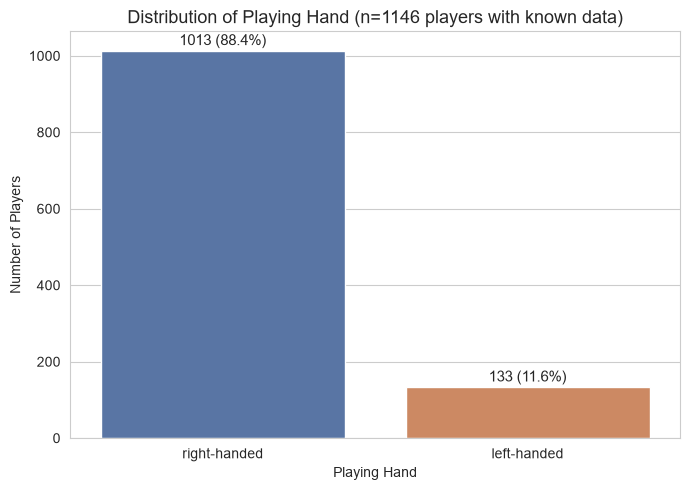

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.figure(figsize=(7, 5))

ax = sns.barplot(x=hand_counts.index, y=hand_counts.values, palette=['#4C72B0', '#DD8452'])

for i, v in enumerate(hand_counts.values):
    pct = hand_percent.values[i]
    ax.text(i, v + 15, f"{v} ({pct:.1f}%)", ha='center', fontsize=11)

plt.title(f"Distribution of Playing Hand (n={len(players_valid)} players with known data)", fontsize=13)
plt.xlabel("Playing Hand")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

**QUESTION 14**

In [10]:
import pandas as pd

tournament_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\tournament.csv")

print("شکل tournament:", tournament_df.shape)
print("ستون‌ها:", list(tournament_df.columns))

print("\nتعداد null در ground_type:", tournament_df['ground_type'].isnull().sum())
print("\n--- مقادیر یکتای ground_type ---")
print(tournament_df['ground_type'].value_counts(dropna=False))

شکل tournament: (35671, 16)
ستون‌ها: ['match_id', 'tournament_id', 'tournament_name', 'tournament_slug', 'tournament_unique_id', 'tournament_category_name', 'tournament_category_slug', 'user_count', 'ground_type', 'tennis_points', 'has_event_player_statistics', 'crowd_sourcing_enabled', 'has_performance_graph_feature', 'display_inverse_home_away_teams', 'priority', 'competition_type']

تعداد null در ground_type: 562

--- مقادیر یکتای ground_type ---
ground_type
Hardcourt outdoor    16959
Red clay             11856
Hardcourt indoor      4741
NaN                    562
Red clay indoor        512
Grass                  509
Carpet indoor          276
Synthetic outdoor      226
Green clay              30
Name: count, dtype: int64


In [11]:
# اول تکراری‌ها رو تمیز می‌کنیم (طبق همون الگوی همیشگی)
tournament_df = tournament_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')

print("بعد از تمیزکاری:", tournament_df.shape)

# دیدگاه ۱: بر اساس تعداد match (هر match یه رای برای سطح زمینش)
print("\n--- توزیع بر اساس تعداد match ---")
match_level = tournament_df['ground_type'].value_counts(dropna=True)
print(match_level)
print(f"\nمتداول‌ترین (بر اساس match): {match_level.index[0]} با {match_level.iloc[0]} match")

# دیدگاه ۲: بر اساس تعداد تورنمنت یکتا (هر تورنمنت فقط یه بار حساب میشه)
tournaments_unique = tournament_df.drop_duplicates(subset='tournament_id')
print("\nتعداد تورنمنت یکتا:", len(tournaments_unique))

print("\n--- توزیع بر اساس تعداد تورنمنت یکتا ---")
tournament_level = tournaments_unique['ground_type'].value_counts(dropna=True)
print(tournament_level)
print(f"\nمتداول‌ترین (بر اساس تورنمنت یکتا): {tournament_level.index[0]} با {tournament_level.iloc[0]} تورنمنت")

بعد از تمیزکاری: (16873, 16)

--- توزیع بر اساس تعداد match ---
ground_type
Hardcourt outdoor    8116
Red clay             5609
Hardcourt indoor     2172
Grass                 242
Red clay indoor       218
Carpet indoor         126
Synthetic outdoor      99
Green clay             18
Name: count, dtype: int64

متداول‌ترین (بر اساس match): Hardcourt outdoor با 8116 match

تعداد تورنمنت یکتا: 535

--- توزیع بر اساس تعداد تورنمنت یکتا ---
ground_type
Hardcourt outdoor    239
Red clay             184
Hardcourt indoor      83
Red clay indoor        6
Grass                  6
Carpet indoor          5
Synthetic outdoor      3
Green clay             1
Name: count, dtype: int64

متداول‌ترین (بر اساس تورنمنت یکتا): Hardcourt outdoor با 239 تورنمنت


**QUESTION 15**

In [1]:
import pandas as pd

home_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\home_team.csv")
away_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\away_team.csv")

# ترکیب کشور بازیکنان از هر دو فایل، یکتا بر اساس player_id
players_country = pd.concat([
    home_df[['player_id', 'country']],
    away_df[['player_id', 'country']]
], ignore_index=True).drop_duplicates(subset='player_id')

print("تعداد کل بازیکن یکتا:", len(players_country))
print("تعداد null در country:", players_country['country'].isnull().sum())

distinct_countries = players_country['country'].dropna().nunique()
print("\nتعداد کشورهای یکتا (بر اساس بازیکنان):", distinct_countries)

print("\n--- لیست همه کشورها ---")
print(sorted(players_country['country'].dropna().unique()))

تعداد کل بازیکن یکتا: 2644
تعداد null در country: 1

تعداد کشورهای یکتا (بر اساس بازیکنان): 100

--- لیست همه کشورها ---
['Algeria', 'Andorra', 'Antigua and Barbuda', 'Argentina', 'Australia', 'Austria', 'Bahamas', 'Barbados', 'Belarus', 'Belgium', 'Bolivia', 'Bosnia & Herzegovina', 'Brazil', 'Bulgaria', 'Burundi', 'Canada', 'Chile', 'China', 'Chinese Taipei', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Guadeloupe', 'Haiti', 'Hong Kong', 'Hungary', 'India', 'Indonesia', 'Iran', 'Ireland', 'Israel', 'Italy', 'Ivory Coast', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kyrgyzstan', 'Latvia', 'Lebanon', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta', 'Mexico', 'Moldova', 'Monaco', 'Morocco', 'Nepal', 'Netherlands', 'New Caledonia', 'New Zealand', 'Nigeria', 'North Macedonia', 'Norway', 'Pakistan', 'Paraguay', 'Peru', 'Phi

In [3]:
venue_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\venue.csv")
venue_df = venue_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')

distinct_venue_countries = venue_df['country'].dropna().nunique()
print("تعداد کشورهای یکتا (بر اساس محل برگزاری):", distinct_venue_countries)

تعداد کشورهای یکتا (بر اساس محل برگزاری): 64


«این دیتاست بازیکنانی از ۱۰۰ کشور مختلف رو شامل میشه، در حالی که تورنمنت‌ها در ۶۴ کشور برگزار شدن — این تفاوت نشون‌دهنده‌ی ماهیت جهانی تنیس حرفه‌ای است، جایی که بازیکنان از کشورهای بیشتری نسبت به کشورهای میزبان تورنمنت شرکت می‌کنن.»

**

اول روشنش کنیم: ستون current_rank که داریم رتبه‌ی فعلی/امروز بازیکنه (وقتی داده استخراج شده)، نه رتبه‌اش در لحظه‌ی اون match خاص. یعنی اگه یه بازیکن الان رتبه ۵ داره ولی موقع اون match رتبه ۵۰ بوده، ما اشتباهی می‌گیمش «حریف تاپ ۱۰». این یه محدودیت داده‌ست که باید تو گزارش ذکر بشه، ولی با همین داده که داریم پیش می‌ریم چون rank تاریخی نداریم.

In [6]:
import pandas as pd

event_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\event.csv")
home_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\home_team.csv")
away_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\away_team.csv")

# تمیزکاری تکراری‌ها (الگوی همیشگی)
event_df = event_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')
home_df = home_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')
away_df = away_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')

event_clean = event_df[['match_id', 'winner_code']].dropna(subset=['winner_code'])
home_clean = home_df[['match_id', 'player_id', 'full_name', 'current_rank']]
away_clean = away_df[['match_id', 'player_id', 'full_name', 'current_rank']]

merged = event_clean.merge(home_clean, on='match_id', how='inner')
merged = merged.merge(away_clean, on='match_id', how='inner', suffixes=('_home', '_away'))

print("شکل نهایی بعد از merge:", merged.shape)
print(merged.head())

شکل نهایی بعد از merge: (8828, 8)
   match_id  winner_code  player_id_home       full_name_home  \
0  11998445          2.0          287803       Cazaux, Arthur   
1  11998446          2.0           62790  Lestienne, Constant   
2  11998447          1.0           64580         Ćorić, Borna   
3  11998448          1.0          131442        Mmoh, Michael   
4  11998449          2.0           22218        Paire, Benoit   

   current_rank_home  player_id_away          full_name_away  \
0               86.0          192013  Auger-Aliassime, Felix   
1               99.0          273680          Flavio Cobolli   
2               31.0           77223         Martinez, Pedro   
3              122.0           88992       Muller, Alexandre   
4              110.0          248846           Mayot, Harold   

   current_rank_away  
0               30.0  
1               69.0  
2              101.0  
3               81.0  
4              132.0  


In [7]:
# رکورد از دید بازیکن home: حریفش away هست
home_perspective = merged[['match_id', 'player_id_home', 'full_name_home', 'current_rank_away', 'winner_code']].copy()
home_perspective = home_perspective.rename(columns={
    'player_id_home': 'player_id',
    'full_name_home': 'player_name',
    'current_rank_away': 'opponent_rank'
})
home_perspective['won'] = home_perspective['winner_code'] == 1

# رکورد از دید بازیکن away: حریفش home هست
away_perspective = merged[['match_id', 'player_id_away', 'full_name_away', 'current_rank_home', 'winner_code']].copy()
away_perspective = away_perspective.rename(columns={
    'player_id_away': 'player_id',
    'full_name_away': 'player_name',
    'current_rank_home': 'opponent_rank'
})
away_perspective['won'] = away_perspective['winner_code'] == 2

# ترکیب هر دو دیدگاه به یه جدول واحد
all_matches_per_player = pd.concat([home_perspective, away_perspective], ignore_index=True)
all_matches_per_player = all_matches_per_player.drop(columns='winner_code')

print("تعداد کل رکورد (هر match دوبار، یه بار برای هر بازیکن):", len(all_matches_per_player))
print(all_matches_per_player.head())

تعداد کل رکورد (هر match دوبار، یه بار برای هر بازیکن): 17656
   match_id  player_id          player_name  opponent_rank    won
0  11998445     287803       Cazaux, Arthur           30.0  False
1  11998446      62790  Lestienne, Constant           69.0  False
2  11998447      64580         Ćorić, Borna          101.0   True
3  11998448     131442        Mmoh, Michael           81.0   True
4  11998449      22218        Paire, Benoit          132.0  False


In [8]:
# فقط matchهایی که حریف رتبه ۱۰ یا بهتر داشته
vs_top10 = all_matches_per_player[all_matches_per_player['opponent_rank'] <= 10].copy()

print("تعداد کل match در مقابل حریف تاپ-۱۰:", len(vs_top10))
print("تعداد بازیکن یکتایی که حداقل یه match مقابل تاپ-۱۰ داشتن:", vs_top10['player_id'].nunique())

# برای هر بازیکن: تعداد کل match، تعداد برد، درصد برد
summary = vs_top10.groupby(['player_id', 'player_name']).agg(
    matches_vs_top10=('won', 'count'),
    wins_vs_top10=('won', 'sum')
).reset_index()

summary['win_pct'] = (summary['wins_vs_top10'] / summary['matches_vs_top10'] * 100).round(1)

# مرتب‌سازی بر اساس درصد برد، نزولی
summary = summary.sort_values(['win_pct', 'matches_vs_top10'], ascending=[False, False])

print("\n--- ۱۵ بازیکن برتر (بر اساس درصد برد مقابل تاپ-۱۰) ---")
print(summary.head(15))

تعداد کل match در مقابل حریف تاپ-۱۰: 226
تعداد بازیکن یکتایی که حداقل یه match مقابل تاپ-۱۰ داشتن: 131

--- ۱۵ بازیکن برتر (بر اساس درصد برد مقابل تاپ-۱۰) ---
     player_id           player_name  matches_vs_top10  wins_vs_top10  win_pct
83      185388          Humbert, Ugo                 3              3    100.0
102     228272          Swiatek, Iga                 3              3    100.0
8        19578     Kerber, Angelique                 1              1    100.0
14       36067       Tsurenko, Lesia                 1              1    100.0
24       47603      Monteiro, Thiago                 1              1    100.0
28       50641          Vekić, Donna                 1              1    100.0
36       59702  Haddad Maia, Beatriz                 1              1    100.0
38       64580          Ćorić, Borna                 1              1    100.0
44       69208      Paolini, Jasmine                 1              1    100.0
50       87690      Thompson, Jordan               

In [9]:
MIN_MATCHES = 2  # حداقل تعداد match مقابل تاپ-۱۰ برای این‌که آمار معنادار باشه

summary_filtered = summary[summary['matches_vs_top10'] >= MIN_MATCHES]

print(f"تعداد بازیکنانی که حداقل {MIN_MATCHES} match مقابل تاپ-۱۰ داشتن:", len(summary_filtered))
print("\n--- رتبه‌بندی نهایی ---")
print(summary_filtered.sort_values(['win_pct', 'matches_vs_top10'], ascending=[False, False]))

تعداد بازیکنانی که حداقل 2 match مقابل تاپ-۱۰ داشتن: 51

--- رتبه‌بندی نهایی ---
     player_id                   player_name  matches_vs_top10  wins_vs_top10  \
83      185388                  Humbert, Ugo                 3              3   
102     228272                  Swiatek, Iga                 3              3   
82      179146              Kalinskaya, Anna                 4              3   
121     275923               Alcaraz, Carlos                 4              3   
9        19728               Cirstea, Sorana                 3              2   
51       89632                Jarry, Nicolas                 3              2   
97      206570                Sinner, Jannik                 3              2   
103     230056                Kostyuk, Marta                 3              2   
12       23581              Dimitrov, Grigor                 6              3   
42       67759        Alexandrova, Ekaterina                 4              2   
95      201239              

حدودیت کلیدی: رتبه‌ای که استفاده کردیم current_rank (رتبه‌ی فعلی/امروز) است، نه رتبه‌ی بازیکن در لحظه‌ی اون match — پس این تحلیل دقیقاً نمی‌گه چه کسی واقعاً موقع بازی با یه حریف تاپ-۱۰ (در اون لحظه) بهتر عمل کرده؛ می‌گه چه کسی مقابل کسی که الان تاپ-۱۰ هست بهتر بوده.
حجم نمونه کوچیک: حتی بهترین‌ها فقط ۳ match دارن — بنابراین "۱۰۰٪ برد" با نمونه‌ی ۳تایی، آماری قوی نیست و باید با احتیاط تفسیر بشه 

**

In [10]:
import pandas as pd

stats_df = pd.read_csv(r"C:\Users\Personal Camputer\OneDrive\Desktop\tennis\statistics.csv")

# دنبال statistic_name هایی که کلمه break توشونه می‌گردیم
break_related = [s for s in stats_df['statistic_name'].dropna().unique() if 'break' in s.lower()]
print("statistic_name های مرتبط با break:")
for b in break_related:
    print(" -", b)

statistic_name های مرتبط با break:
 - break_points_saved
 - break_points_converted
 - tiebreaks


In [11]:
bp_df = stats_df[stats_df['statistic_name'] == 'break_points_converted']

print("تعداد ردیف:", len(bp_df))
print("\nمقادیر یکتای period:")
print(bp_df['period'].value_counts())

print("\n--- نمونه ردیف‌ها ---")
print(bp_df[['match_id', 'period', 'home_stat', 'away_stat', 'home_value', 'away_value']].head(10))

تعداد ردیف: 76265

مقادیر یکتای period:
period
ALL    23291
1ST    23197
2ND    22823
3RD     6954
Name: count, dtype: int64

--- نمونه ردیف‌ها ---
     match_id period home_stat away_stat  home_value  away_value
18   11998445    ALL         5         4           5           4
35   11998445    1ST         1         2           1           2
52   11998445    2ND         2         0           2           0
69   11998445    3RD         2         2           2           2
89   11998446    ALL         1         5           1           5
106  11998446    1ST         0         1           0           1
123  11998446    2ND         1         4           1           4
143  11998447    ALL         4         0           4           0
160  11998447    1ST         1         0           1           0
176  11998447    2ND         3         0           3           0


In [12]:
# فیلتر فقط period == ALL
breaks_all = stats_df[
    (stats_df['statistic_name'] == 'break_points_converted') & 
    (stats_df['period'] == 'ALL')
].copy()

print("قبل از حذف تکراری:", breaks_all.shape)

breaks_all = breaks_all.drop_duplicates()
breaks_all = breaks_all.drop_duplicates(subset='match_id', keep='first')

print("بعد از حذف تکراری:", breaks_all.shape)

# تبدیل به عدد (برای احتیاط، هرچند به نظر از قبل عدده)
breaks_all['home_stat_num'] = pd.to_numeric(breaks_all['home_stat'], errors='coerce')
breaks_all['away_stat_num'] = pd.to_numeric(breaks_all['away_stat'], errors='coerce')

print("\nتعداد NaN بعد از تبدیل - home:", breaks_all['home_stat_num'].isnull().sum())
print("تعداد NaN بعد از تبدیل - away:", breaks_all['away_stat_num'].isnull().sum())

# جمع زدن کل breakهای هر match (home + away)
breaks_all['total_breaks'] = breaks_all['home_stat_num'] + breaks_all['away_stat_num']

print("\n--- آمار توصیفی total_breaks ---")
print(breaks_all['total_breaks'].describe())

avg_breaks = breaks_all['total_breaks'].mean()
print(f"\nمیانگین تعداد break of serve در هر match: {avg_breaks:.2f}")

قبل از حذف تکراری: (23291, 13)
بعد از حذف تکراری: (11393, 13)

تعداد NaN بعد از تبدیل - home: 0
تعداد NaN بعد از تبدیل - away: 0

--- آمار توصیفی total_breaks ---
count    11393.000000
mean         6.620030
std          3.133333
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         29.000000
Name: total_breaks, dtype: float64

میانگین تعداد break of serve در هر match: 6.62


مثل aces، این عدد فقط بر پایه‌ی ۱۱۳۹۳ match (حدود ۳۲٪ از کل ۳۵۰۵۳ match دیتاست) هست — یعنی نزدیک به ۳ سوم matchها اصلاً این آمار جزئی (statistics) رو نداشتن. این باید تو گزارش ذکر بشه که نتیجه فقط نماینده‌ی زیرمجموعه‌ای از matchهاست که آمار کامل ثبت شده براشون، نه کل دیتاست.

نکته‌ی جالب برای تحلیل بیشتر (اختیاری): اگه بخوای عمیق‌تر بری، می‌تونی این رو هم با aces مقایسه کنی — بازیکنایی که ایس بیشتری می‌زنن (سرویس قوی‌تر) معمولاً باید break کمتری بخورن، پس شاید یه correlation منفی جالب بین میانگین ایس هر match و میانگین break اون match پیدا بشه. می‌خوای این تحلیل رو هم انجام بدیم؟